# Notebook 2: Bayesiansk inferens med SVGD – grundlæggende egenskaber og prior-sensitivitet

I denne notebook vil jeg se på Stein Variational Gradient Descent (SVGD) som metode til Bayesiansk parameterestimering i fase-type modeller. Jeg starter med en single-parameter koalescent og undersøger, hvordan valget af prior, lærings rate og regularisering påvirker konvergens og posterior-præcision. Jeg undersøger desuden prøvestørrelse-effekter og posterior-bredde.

**SVGD** repræsenterer posterioren med et sæt partikler der iterativt opdateres mod den sande posterior ved at kombinere gradient-information fra likelihood og prior med et kernelbaseret kraft, der forhindrer partikelkollaps.

In [ ]:
# Importer de nødvendige pakker
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"


from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior,
    Adam, ExpStepSize, ExpRegularization,
    clear_caches,
) 
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (9, 4)

clear_caches()

  Removed 1 file(s), preserved directory structure
  Removed 1 file(s), preserved directory structure


In [2]:
# Standard parameteriseret koalescent
# theta[0] = koalescensrate (1/N)
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
true_theta = [7.0]
graph.update_weights(true_theta)

## Prior-sensitivitet: Hvor meget betyder prior-valget?

SVGD er en Bayesiansk metode, og prioren spiller en central rolle især for små datasæt. Jeg undersøger tre scenarier: vag Gaussisk prior, informativ Gaussisk prior og Half-Cauchy prior.

### Hypotese 

- En informativ, men korrekt centreret prior konvergerer hurtigere og giver smallere posterior end en vag prior. En vag prior med store sample sizes konvergerer til det samme resultat som en informativ prior.

Jeg forventer: ved $n_{obs} = 10.000$ er prioren næsten irrelevant, men ved $n_{obs} = 100$ dominerer prioren stærkt.

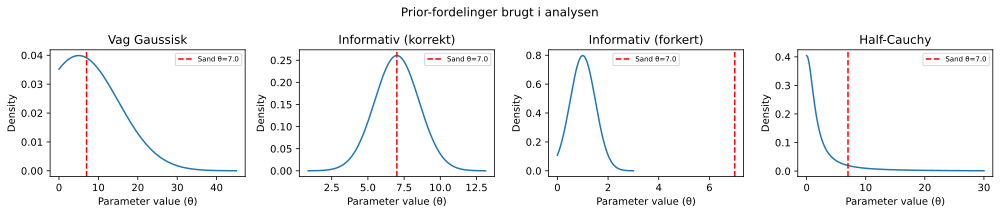

In [3]:
# Simuler data med kendt sand parameter
N_OBS = 2000
observed_data = graph.sample(N_OBS)

# Tre priors: vag, informativ (korrekt), og Half-Cauchy
prior_vag = GaussPrior(mean=5.0, std=10.0) # vag
prior_korrekt = GaussPrior(ci=[4.0, 10.0]) # informativ, korrekt centreret
prior_forkert = GaussPrior(mean=1.0, std=0.5) # informativ, forkert centreret
prior_halfcauchy = HalfCauchyPrior(ci=20.0) 

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, prior, title in zip(axes,
    [prior_vag, prior_korrekt, prior_forkert, prior_halfcauchy],
    ['Vag Gaussisk', 'Informativ (korrekt)', 'Informativ (forkert)', 'Half-Cauchy']):
    prior.plot(ax=ax, return_ax=True)
    ax.axvline(true_theta[0], color='red', linestyle='--', label=f'Sand θ={true_theta[0]}')
    ax.set_title(title)
    ax.legend(fontsize=7)
plt.suptitle('Prior-fordelinger brugt i analysen', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Kører SVGD med alle fire priors og sammenligner
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
svgd_results = {}

for name, prior in [('Vag', prior_vag), ('Korrekt', prior_korrekt),
                     ('Forkert', prior_forkert), ('HalfCauchy', prior_halfcauchy)]:
    svgd = graph.svgd(observed_data, prior=prior, learning_rate=step, n_iterations=300)
    res = svgd.get_results()
    svgd_results[name] = {
        'svgd': svgd,
        'mean': res['theta_mean'].item(),
        'std':  res['theta_std'].item(),
        'ci_low':  res['ci_low'].item(),
        'ci_high': res['ci_high'].item(),
    }
    print(f"{name:<12}: θ_mean={res['theta_mean'].item():.3f}  "
          f"std={res['theta_std'].item():.3f}  "
          f"95%CI=[{res['ci_low'].item():.2f}, {res['ci_high'].item():.2f}]")

print(f"\nSand θ = {true_theta[0]}")

HalfCauchy  : θ_mean=7.052  std=0.122  

Sand θ = 7.0


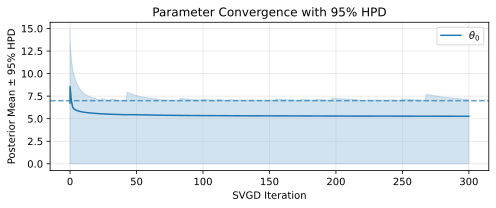

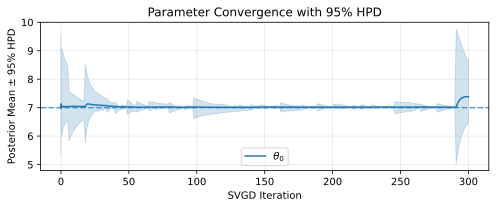

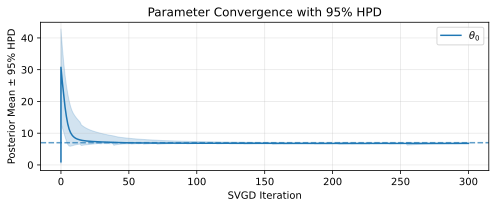

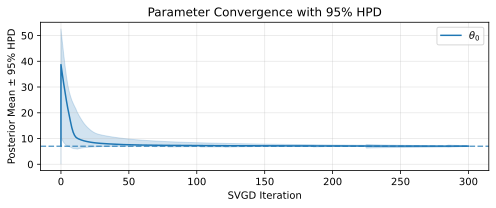

In [12]:
# Visualiser posterior under de fire priors side om side
for ax, (name, res) in zip(axes, svgd_results.items()):
    res['svgd'].plot_ci(true_theta=true_theta)
    ax.set_title(f"{name}\n(mean={res['mean']:.2f}, std={res['std']:.2f})")


### Hypotese: Prior dominans som funktion af prøvestørrelse

- Ved lav prøvestørrelse ($n < 200$) dominerer prioren stærkt. Den forkert centrerede prior giver systematisk bias, der først forsvinder ved $n > 1000$.

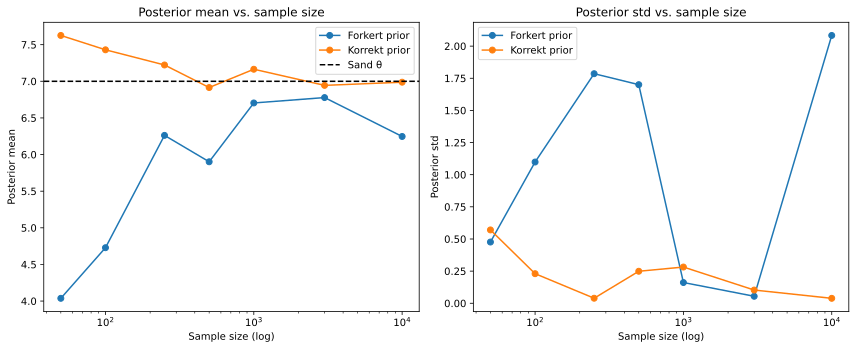

    n         prior     mean      std
   50 Korrekt prior 7.625729 0.570384
   50 Forkert prior 4.037449 0.476175
  100 Korrekt prior 7.429762 0.230021
  100 Forkert prior 4.728250 1.098430
  250 Korrekt prior 7.222611 0.039121
  250 Forkert prior 6.261756 1.785404
  500 Korrekt prior 6.914896 0.248953
  500 Forkert prior 5.901321 1.700153
 1000 Korrekt prior 7.164397 0.281737
 1000 Forkert prior 6.704279 0.161184
 3000 Korrekt prior 6.944316 0.102710
 3000 Forkert prior 6.777731 0.054336
10000 Korrekt prior 6.987697 0.038445
10000 Forkert prior 6.246759 2.082863


In [ ]:
# Prior-dominans: sammenlign korrekt vs. forkert prior over prøvestørrelser
sample_sizes = [50, 100, 250, 500, 1000, 3000, 10000]
rows = []

for n in sample_sizes:
    data_n = graph.sample(n)
    for prior_name, prior in [('Korrekt prior', prior_korrekt), ('Forkert prior', prior_forkert)]:
        sv = graph.svgd(data_n, prior=prior, learning_rate=step, n_iterations=300)
        res = sv.get_results()
        rows.append({
            'n': n, 'prior': prior_name,
            'mean': res['theta_mean'].item(),
            'std':  res['theta_std'].item(),
        })

df_prior = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for prior_name, grp in df_prior.groupby('prior'):
    axes[0].plot(grp['n'], grp['mean'], marker='o', label=prior_name)
    axes[1].plot(grp['n'], grp['std'],  marker='o', label=prior_name)

axes[0].axhline(true_theta[0], color='black', linestyle='--', label='Sand θ')
axes[0].set_xscale('log'); axes[0].set_xlabel('Prøvestørrelse (log)'); axes[0].set_ylabel('Posterior mean')
axes[0].set_title('Posterior mean vs. prøvestørrelse'); axes[0].legend()

axes[1].set_xscale('log'); axes[1].set_xlabel('Prøvestørrelse (log)'); axes[1].set_ylabel('Posterior std')
axes[1].set_title('Posterior std vs. prøvestørrelse'); axes[1].legend()
plt.tight_layout()
plt.show()
print(df_prior.to_string(index=False))

## Læringsrate og konvergens

SVGD's konvergens afhænger stærkt af læringsraten. Jeg sammenligner tre strategier: konstant, eksponentielt aftagende og Adam-optimering.

### Hypotese

- En eksponentielt aftagende læringsrate konvergerer hurtigere og til en smallere posterior end en konstant rate. Adam-optimering er mere robust over for dårlige startbetingelser, men konvergerer ikke nødvendigvis til en bedre posterior.

Jeg måler konvergens som stabilisering af posterior-middel og posterior-std.

In [14]:
observed_data = graph.sample(2000)
prior = prior_korrekt
N_ITER = 400

# Tre optimeringsstrategier
strategies = {
    'Konstant (0.01)': {'learning_rate': 0.01},
    'Konstant (0.05)': {'learning_rate': 0.05},
    'ExpStepSize (tau=30)': {'learning_rate': ExpStepSize(first_step=0.1, last_step=0.005, tau=30.0)},
    'ExpStepSize (tau=100)': {'learning_rate': ExpStepSize(first_step=0.1, last_step=0.005, tau=100.0)},
    'Adam (lr=0.25)': {'optimizer': Adam(learning_rate=0.25)},
}

svgd_conv = {}
for name, kwargs in strategies.items():
    sv = graph.svgd(observed_data, prior=prior, n_iterations=N_ITER, **kwargs)
    res = sv.get_results()
    svgd_conv[name] = {'svgd': sv, 'mean': res['theta_mean'].item(), 'std': res['theta_std'].item()}
    print(f"{name:<30}: mean={res['theta_mean'].item():.3f}  std={res['theta_std'].item():.3f}")
print(f"Sand θ = {true_theta[0]}")

Adam (lr=0.25)                : mean=6.914  std=0.077
Sand θ = 7.0


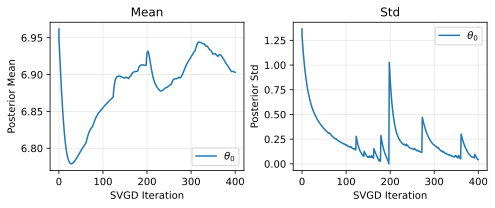

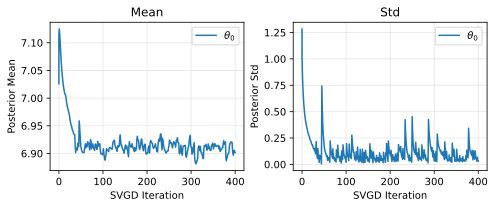

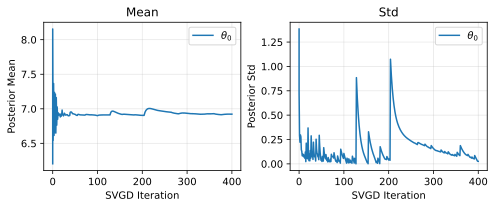

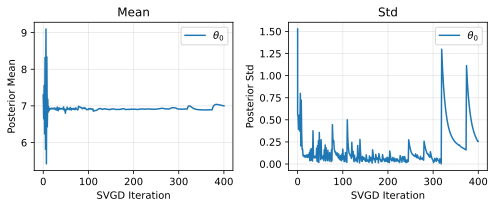

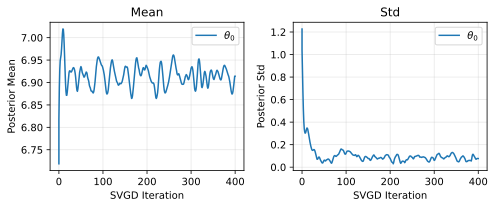

In [18]:
# Konvergensplots for alle strategier
for ax, (name, res) in zip(axes, svgd_conv.items()):
    res['svgd'].plot_convergence()
    ax.set_title(name, fontsize=9)
    ax.axhline(true_theta[0], color='red', linestyle='--', linewidth=1)


## Regularisering og posterior-kollaps

Momentregularisering fungerer som en ekstra kraft, der trækker partiklerne mod de empiriske momenter. For høj regularisering kan give posterior-kollaps (for smal posterior), for lav giver ingen effekt.

### Hypotese 

- Stærk regularisering ($\text{reg} >> 1$) i de tidlige iterationer stabiliserer konvergens og reducerer risikoen for partikel-divergens, men overdreven regularisering over alle iterationer fører til systematisk underdisperseret posterior.

In [20]:
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

reg_schedules = {
    'Ingen regularisering': None,
    'Svag (1→0.01)': ExpRegularization(first_reg=1.0, last_reg=0.01, tau=20.0),
    'Moderat (10→0.1)': ExpRegularization(first_reg=10.0, last_reg=0.1, tau=20.0),
    'Stærk konstant (50)': ExpRegularization(first_reg=50.0, last_reg=50.0, tau=1000.0),
}

svgd_reg = {}
for name, reg in reg_schedules.items():
    kwargs = {'learning_rate': step, 'prior': prior_korrekt, 'n_iterations': 300, 'nr_moments': 2}
    if reg is not None:
        kwargs['regularization'] = reg
    sv = graph.svgd(observed_data, **kwargs)
    res = sv.get_results()
    svgd_reg[name] = {'svgd': sv, 'mean': res['theta_mean'].item(), 'std': res['theta_std'].item()}
    print(f"{name:<30}: mean={res['theta_mean'].item():.3f}  std={res['theta_std'].item():.4f}")
print(f"Sand θ = {true_theta[0]}")

Stærk konstant (50)           : mean=6.954  std=0.4123
Sand θ = 7.0


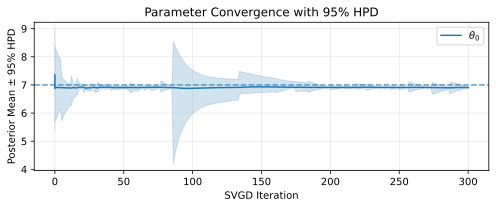

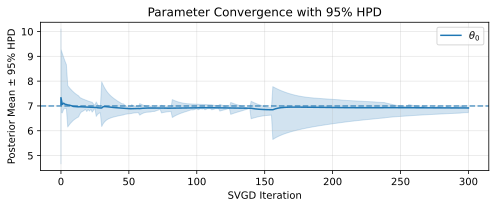

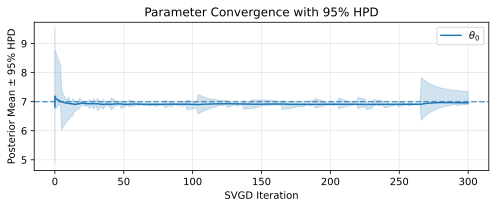

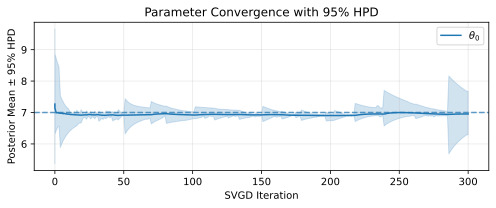

In [ ]:
# Viser posterior width (std) som funktion af regulariseringsstyrke
for ax, (name, res) in zip(axes, svgd_reg.items()):
    res['svgd'].plot_ci(true_theta=true_theta)
    ax.set_title(f'{name}\nstd={res["std"]:.4f}', fontsize=8)


## Posterior-validering: Dækker 95% CI den sande parameter?

Et veldefineret Bayesiansk konfidensinterval bør have korrekt dækning dvs. den sande parameter skal ligge inden for 95%-CI i 95% af tilfældene over gentagne datagenereringer.

### Hypotese 

- Dækningsfrekvensen for 95%-CI er tæt på 0.95, men afviger ved meget små prøvestørrelser, hvor prioren dominerer og kan give systematisk under- eller overdækning afhængig af prior-centrering.

In [ ]:
# StopIterationimuler gentagne inferenser
N_REPS = 50  # antal gentagelser per sample size
step_cov  = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
coverage_results = []

for n_obs in [100, 500, 2000]:
    covered_korrekt = 0
    covered_forkert = 0
    means_k, means_f = [], []
    for rep in range(N_REPS):
        data_rep = graph.sample(n_obs)
        for prior_name, prior_obj, results_list in [
            ('Korrekt', prior_korrekt, None),
            ('Forkert',  prior_forkert, None)
        ]:
            sv = graph.svgd(data_rep, prior=prior_obj, learning_rate=step_cov, n_iterations=200)
            res = sv.get_results()
            ci_low  = res['ci_low'].item()
            ci_high = res['ci_high'].item()
            covered = int(ci_low <= true_theta[0] <= ci_high)
            mean_val = res['theta_mean'].item()
            if prior_name == 'Korrekt':
                covered_korrekt += covered
                means_k.append(mean_val)
            else:
                covered_forkert += covered
                means_f.append(mean_val)
    coverage_results.append({
        'n': n_obs,
        'Coverage (korrekt prior)': covered_korrekt / N_REPS,
        'Coverage (forkert prior)': covered_forkert / N_REPS,
        'Mean bias (korrekt)': round(np.mean(means_k) - true_theta[0], 4),
        'Mean bias (forkert)': round(np.mean(means_f) - true_theta[0], 4),
    })

df_cov = pd.DataFrame(coverage_results)
print(df_cov.to_string(index=False))

In [ ]:
# Visualiser coverage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_cov['n'], df_cov['Coverage (korrekt prior)'], marker='o', label='Korrekt prior')
ax.plot(df_cov['n'], df_cov['Coverage (forkert prior)'], marker='s', label='Forkert prior')
ax.axhline(0.95, color='black', linestyle='--', label='Nominel dækning (0.95)')
ax.set_xscale('log')
ax.set_xlabel('Sample size'); ax.set_ylabel('Empirisk 95%-CI dækning')
ax.set_title(f'Coverage-analyse ({N_REPS} replikater per sample size)')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Posterior predictive check

Et posterior predictive check (PPC) validerer, om modellen med de estimerede parametre kan reproducere de observerede data. Jeg sammenligner empirisk CDF med den fittede model CDF.

### Hypotese 

- Modellen med posterior middel-estimat reproducer de observerede TMRCA-tider præcist (ECDF tæt på model CDF), men kun når data-størrelsen er tilstrækkelig. For forkert prior med lille sample size forventes systematisk afvigelse.

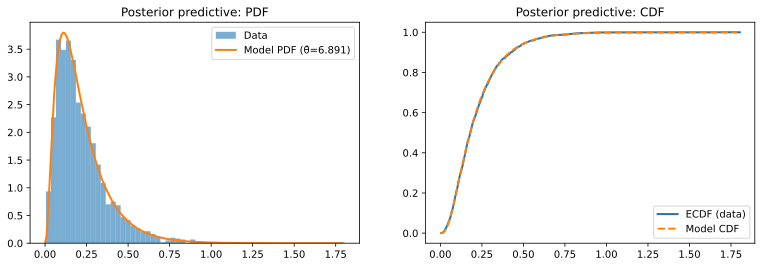

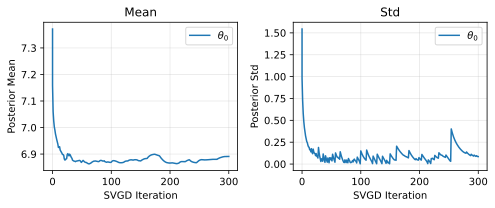

<Figure size 900x400 with 0 Axes>

In [ ]:
from scipy.stats import ecdf

# SVGD med korrekt prior og N=2000
observed_data = graph.sample(2000)
svgd_final = graph.svgd(observed_data, prior=prior_korrekt,
                         learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0),
                         n_iterations=300)
res = svgd_final.get_results()
theta_hat = res['theta_mean'].item()

# Posterior predictive check
res_ecdf = ecdf(observed_data)
x_ecdf = res_ecdf.cdf.quantiles
y_ecdf = res_ecdf.cdf.probabilities

graph.update_weights([theta_hat])
x_range = np.linspace(0, max(observed_data)*0.99, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram + PDF
axes[0].hist(observed_data, bins=60, density=True, alpha=0.6, label='Data')
axes[0].plot(x_range, graph.pdf(x_range), 'C1', lw=2, label=f'Model PDF (θ̂={theta_hat:.3f})')
axes[0].set_title('Posterior predictive: PDF'); axes[0].legend()

# ECDF vs CDF
axes[1].plot(x_ecdf, y_ecdf, 'C0', lw=2, label='ECDF (data)')
axes[1].plot(x_range, graph.cdf(x_range), 'C1', lw=2, linestyle='--', label='Model CDF')
axes[1].set_title('Posterior predictive: CDF'); axes[1].legend()

# Konvergence
svgd_final.plot_convergence()

# Nulstil til sand parameter
graph.update_weights(true_theta)